In [28]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [29]:
# Generate some sample data
df = pd.DataFrame({
    "X1": [1, 2, 3, 4, 5, 6, 6, 7, 9, 9],
    "X2": [5, 3, 6, 8, 1, 9, 5, 8, 9, 2],
    "Label": [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]
})

In [30]:
df

,X1,X2,Label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

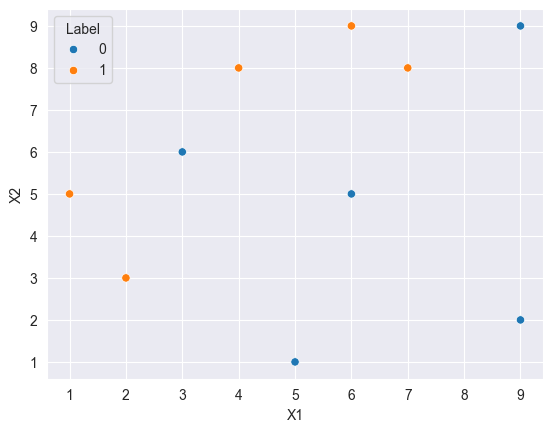

In [31]:
# Visualize the data
import seaborn as sns
sns.scatterplot(x=df["X1"], y=df["X2"], hue=df["Label"])

In [32]:
# Assigning equal weights to each row
df["weights"] = 1/df.shape[0]
df

,X1,X2,Label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
# Creating a Decision Stump
dt1 = DecisionTreeClassifier(max_depth=1)

In [35]:
# Extracting X and Y
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

In [36]:
# Train 1st model
dt1.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

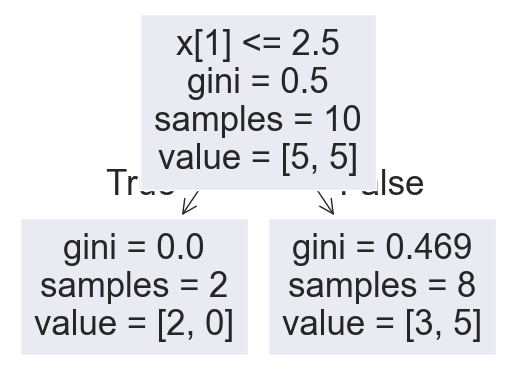

In [37]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

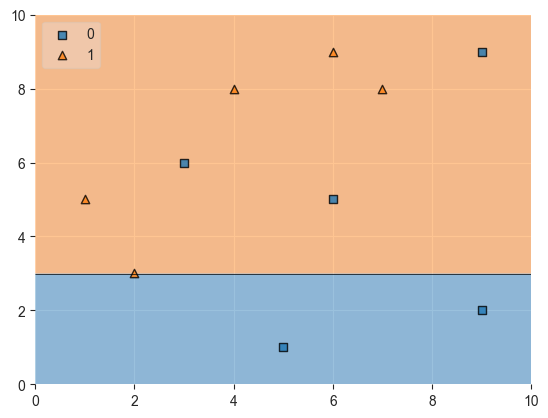

In [38]:
# Decision Boundary
plot_decision_regions(X, y, clf=dt1, legend=2)

In [39]:
# Getting predictions on the training data
df["y_pred"] = dt1.predict(X)
df

,X1,X2,Label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [40]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/error)

In [41]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [42]:
# Update weights
def update_weights(row, alpha=0.4236):
  if row["Label"] == row["y_pred"]:
    return row["weights"] * np.exp(-alpha)
  else:
    return row["weights"] * np.exp(alpha)

In [43]:
df["updated_weights"] = df.apply(update_weights, axis=1)
df

,X1,X2,Label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065469
1,2,3,1,0.1,1,0.065469
2,3,6,0,0.1,1,0.152745
3,4,8,1,0.1,1,0.065469
4,5,1,0,0.1,0,0.065469
5,6,9,1,0.1,1,0.065469
6,6,5,0,0.1,1,0.152745
7,7,8,1,0.1,1,0.065469
8,9,9,0,0.1,1,0.152745
9,9,2,0,0.1,0,0.065469


In [44]:
# The sum of updated weights is not 1
df["updated_weights"].sum()

np.float64(0.9165151400883117)

In [45]:
# So we have to normalize it
df["Normalized Weights"] = df["updated_weights"] / df["updated_weights"].sum()
df

,X1,X2,Label,weights,y_pred,updated_weights,Normalized Weights
0,1,5,1,0.1,1,0.065469,0.071432
1,2,3,1,0.1,1,0.065469,0.071432
2,3,6,0,0.1,1,0.152745,0.166659
3,4,8,1,0.1,1,0.065469,0.071432
4,5,1,0,0.1,0,0.065469,0.071432
5,6,9,1,0.1,1,0.065469,0.071432
6,6,5,0,0.1,1,0.152745,0.166659
7,7,8,1,0.1,1,0.065469,0.071432
8,9,9,0,0.1,1,0.152745,0.166659
9,9,2,0,0.1,0,0.065469,0.071432


In [46]:
# Now the sum is equal to 1
df["Normalized Weights"].sum()

np.float64(1.0)

# Creating a range

In [47]:
df["cumsum_upper"] = np.cumsum(df["Normalized Weights"])
df["cumsum_lower"] = np.cumsum(df["Normalized Weights"]) - df["Normalized Weights"]

In [48]:
df[['X1','X2','Label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,Label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065469,0.000000,0.071432
1,2,3,1,0.1,1,0.065469,0.071432,0.142864
2,3,6,0,0.1,1,0.152745,0.142864,0.309523
3,4,8,1,0.1,1,0.065469,0.309523,0.380955
4,5,1,0,0.1,0,0.065469,0.380955,0.452387
5,6,9,1,0.1,1,0.065469,0.452387,0.523819
6,6,5,0,0.1,1,0.152745,0.523819,0.690477
7,7,8,1,0.1,1,0.065469,0.690477,0.761909
8,9,9,0,0.1,1,0.152745,0.761909,0.928568
9,9,2,0,0.1,0,0.065469,0.928568,1.000000


In [49]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [50]:
index_values = create_new_dataset(df)
index_values

[8, 6, 7, 0, 2, 4, 8, 4, 6, 0]

In [51]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [52]:
second_df

,X1,X2,Label,weights
8,9,9,0,0.1
6,6,5,0,0.1
7,7,8,1,0.1
0,1,5,1,0.1
2,3,6,0,0.1
4,5,1,0,0.1
8,9,9,0,0.1
4,5,1,0,0.1
6,6,5,0,0.1
0,1,5,1,0.1


In [53]:
from sklearn.preprocessing import StandardScaler